[Land sea mask loader]
Elapsed: 0.1575157642364502


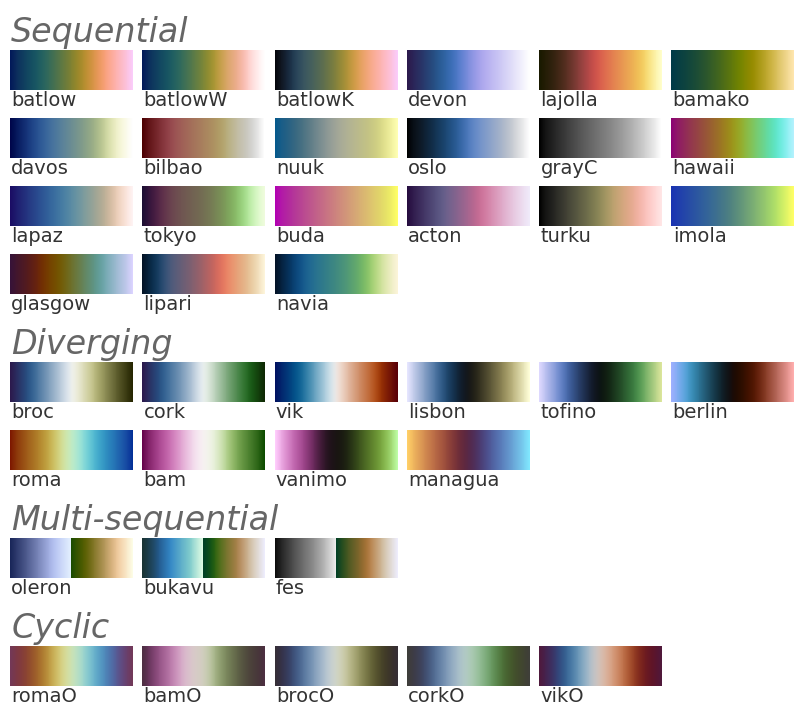

In [1]:
#Define my working directory (important for modules)
import os
os.chdir('/nfs/mary/Users/eelse/scripts/jupyter')

%matplotlib inline
import xarray as xr
import cartopy.feature
import cartopy.crs as ccrs
import matplotlib.pyplot as plt
from matplotlib.colors import BoundaryNorm, TwoSlopeNorm, LinearSegmentedColormap, ListedColormap, Normalize
import cmcrameri.cm as cmc

import numpy as np

import mw_protocol.plotting as plotting
import mw_protocol.glac1d_toolbox as tb

import mymodules.myfunc as mf 

import cftime
import regionmask
import geopandas as gpd
import pandas as pd
import pickle

#landmask
with mf.Timer('Land sea mask loader'):
    data_folder = f"/nfs/annie/eeymr/work/data/publication/ROME2022_paleoceanography_oscillations"
    ds_lsm = xr.open_dataset(f"{data_folder}/lgm_inputs/temev.qrparm.omask.nc")
    lsm = ds_lsm.lsm

from cmcrameri import show_cmaps
show_cmaps()


In [2]:
# Make or Load the Mean Dyefield Computation 

from mymodules.dyefield_computation import run_pipeline
from myconfig.EXPERIMENTS import EXPERIMENTS

results = run_pipeline(
    experiments=EXPERIMENTS,
    outdir="myintermediates/dyestuff_modelpaper/",
    keep_in_memory=True, # put it in my jupyter Notebook memory
    save=True,
    overwrite=False, # If the data is already there - do not overwrite but just lazy load the existing files
    exclude=('xqeic','xqeie'), #simulations to be excluded here from the total experiments
    preflight=False, #You need to make this false if you don't need it, else it takes time!
)




===== COLD =====


cold: 100%|███████████████████████████████| 5/5 [00:00<00:00,  9.60experiment/s]



===== MERID =====


merid: 100%|██████████████████████████████| 4/4 [00:00<00:00, 11.11experiment/s]



===== ZONAL =====


zonal: 100%|██████████████████████████████| 4/4 [00:00<00:00, 13.05experiment/s]


✓ Pipeline finished.


In [3]:
import importlib
import mymodules.dyefield_computation as dc

importlib.reload(dc)

from mymodules.dyefield_computation import build_dye_field_lookup


dye_field_lookup = build_dye_field_lookup(results,depth_index=0)

/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered i

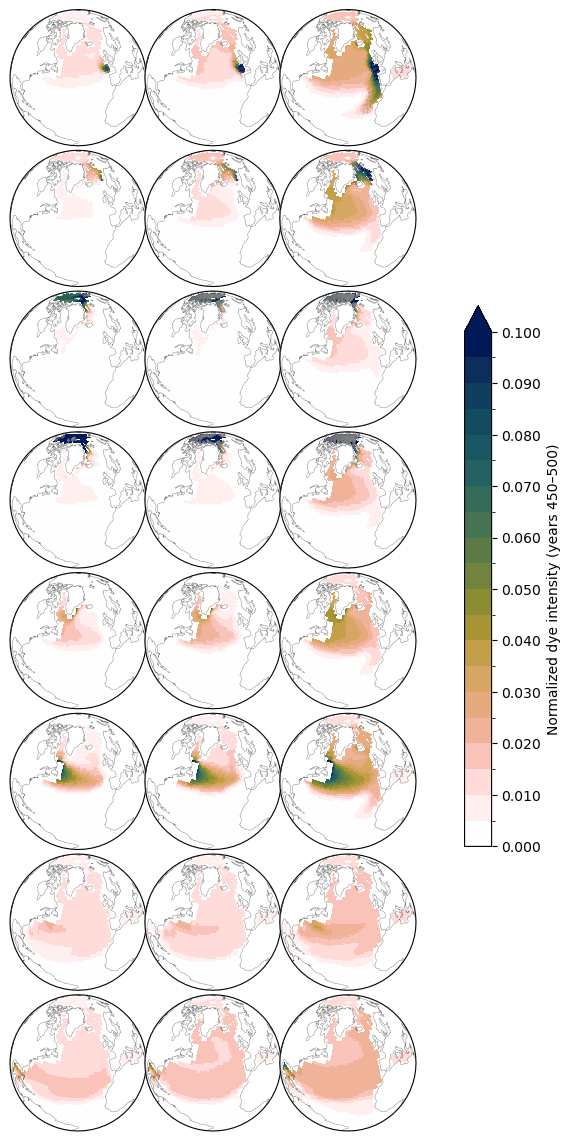

In [4]:
# --------------------------------------------------
# Plot mean dye fields + uncertainty stippling
# --------------------------------------------------

from matplotlib import colors
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl
from matplotlib.colors import ListedColormap


projection_map = ccrs.NearsidePerspective(
    central_longitude=-35,
    central_latitude=45,
    satellite_height=11000000
)


# -------------------------
# Dye settings
# -------------------------

bounds = np.arange(0, 0.101, 0.005)
std_threshold = 0.01   # 10% of max


normdye_a = mpl.colors.BoundaryNorm(
    boundaries=bounds,
    ncolors=cmc.hawaii_r.N
)

dye_list = (
    'dye01','dye02','dye03','dye04',
    'dye05','dye06','dye07','dye08'
)

states = ['merid', 'zonal', 'cold']



# -------------------------
# Figure
# -------------------------

figMap, axMap = plt.subplots(
    nrows=len(dye_list),
    ncols=len(states),
    subplot_kw={'projection': projection_map},
    figsize=(5.8, 11.7)
)


# ensure axes is always 2D
axMap = np.atleast_2d(axMap)


# -------------------------
# Loop modes
# -------------------------

for j, mode in enumerate(states):

    for i, dye in enumerate(dye_list):

        ax = axMap[i, j]


        # -------------------------
        # Background land
        # -------------------------

        #ax.pcolormesh(
        #    ds_lsm.longitude,
        #    ds_lsm.latitude,
        #    xr.where(
        #        ds_lsm.lsm == 0,
        #        np.nan,
        #        ds_lsm.lsm
        #    ),
        #    cmap=ListedColormap(['#cccccc']),
        #    transform=ccrs.PlateCarree(),
        #    shading="nearest",
        #    zorder=1
        #)


        # -------------------------
        # Mean dye field
        # -------------------------

        mean_field = dye_field_lookup[mode]["mean"][dye]

        mean_smooth = (
            mean_field
            .rolling(
                latitude=3,
                longitude=3,
                center=True
            )
            .mean()
        )


        pcm = ax.pcolormesh(
            mean_smooth.longitude,
            mean_smooth.latitude,
            mean_smooth,
            transform=ccrs.PlateCarree(),
            norm=normdye_a,
            cmap=cmc.batlowW_r,
            shading="nearest",
            zorder=2
        )


        # -------------------------
        # Relative uncertainty
        # -------------------------

        std_field = dye_field_lookup[mode]["std"][dye]

        mask = std_field > std_threshold 


        # coordinates for stippling
        xx, yy = np.meshgrid(
            mean_field.longitude,
            mean_field.latitude
        )


        ax.scatter(
            xx[::2, ::2][mask.values[::2, ::2]],
            yy[::2, ::2][mask.values[::2, ::2]],
            s=0.25,
            color="grey",
            marker=".",
            transform=ccrs.PlateCarree(),
            zorder=5
        )


        # -------------------------
        # Map formatting
        # -------------------------

        ax.coastlines(
            resolution='110m',
            linewidth=0.25,
            color='0.2',
            alpha=0.8,
            zorder=4
        )


# -------------------------
# Colorbar
# -------------------------

cb = figMap.colorbar(
    pcm,
    ax=axMap.ravel().tolist(),
    location="right",
    shrink=0.6,
    extend="max",
    pad=0.15,
    boundaries=bounds,
    ticks=bounds
)

cb.set_label(
    "Normalized dye intensity (years 450–500)"
)

cb.ax.set_yticks(bounds[::2])
cb.ax.set_yticklabels(
    [f"{b:.3f}" for b in bounds[::2]]
)


plt.subplots_adjust(
    wspace=-0.01,
    hspace=0.02,
    top=0.98,
    bottom=0.02,
    left=0,
    right=0.7
)

#
#plt.savefig(
#    "compare_mean_amocstates_rev.pdf",
#    dpi=600,
#    bbox_inches="tight"
#)

/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered i

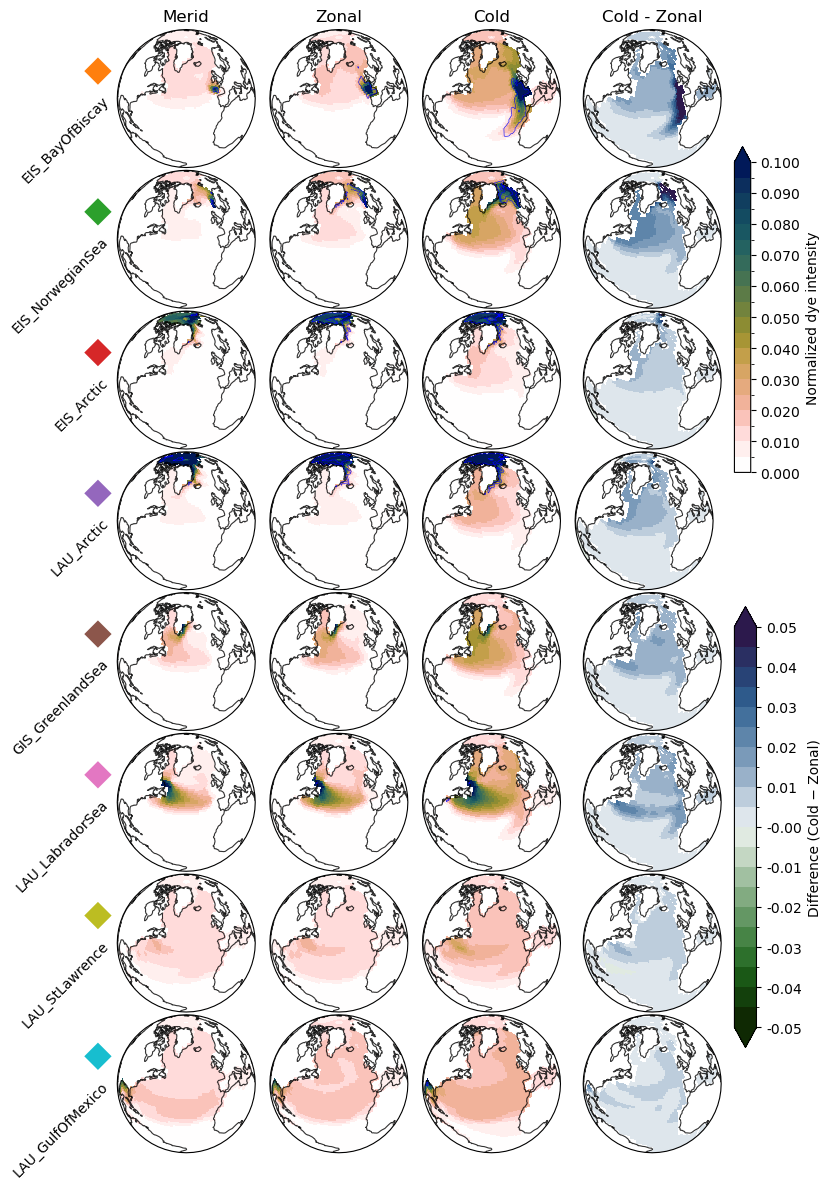

In [26]:
# --------------------------------------------------
# Plot mean dye fields + uncertainty stippling
# + Cold - Zonal difference column
# --------------------------------------------------

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import warnings

# Dye and d18O information
from myconfig.DYES import DYE_TABLE
#DYE_TO_REGION = dict(zip(DYE_TABLE["dye"], DYE_TABLE["region"]))

projection_map = ccrs.NearsidePerspective(
    central_longitude=-35,
    central_latitude=45,
    satellite_height=11000000,
)

# -------------------------
# Dye settings
# -------------------------

bounds = np.arange(0, 0.101, 0.005)
std_threshold = 0.01

normdye_a = mpl.colors.BoundaryNorm(
    boundaries=bounds,
    ncolors=cmc.batlowW_r.N,
)

# Difference colour scale
diff_lim = 0.05
diff_bounds = np.arange(-diff_lim, diff_lim + 0.005, 0.005)

diff_norm = mpl.colors.BoundaryNorm(
    boundaries=diff_bounds,
    ncolors=cmc.broc.N,
)

dye_list = (
    "dye01",
    "dye02",
    "dye03",
    "dye04",
    "dye05",
    "dye06",
    "dye07",
    "dye08",
)

states = ["merid", "zonal", "cold"]


region_names = DYE_TABLE["region"].tolist()[1:]

region_colors = {
    region: color
    for region, color in zip(
        region_names,
        [
            #"tab:blue",
            "tab:orange",
            "tab:green",
            "tab:red",
            "tab:purple",
            "tab:brown",
            "tab:pink",
            "tab:olive",
            "tab:cyan",
        ],
    )
}




# -------------------------
# Figure
# -------------------------

figMap, axMap = plt.subplots(
    nrows=len(dye_list),
    ncols=4,
    subplot_kw={"projection": projection_map},
    figsize=(9, 11.7),
)

axMap = np.atleast_2d(axMap)

# --------------------------------------------------
# First three columns
# --------------------------------------------------

for j, mode in enumerate(states):

    for i, dye in enumerate(dye_list):

        ax = axMap[i, j]

        # -------------------------
        # Mean field
        # -------------------------

        mean_field = dye_field_lookup[mode]["mean"][dye]

        

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="invalid value encountered in divide",
                category=RuntimeWarning,
            )
        

        mean_smooth = (
            mean_field
            .rolling(latitude=3, longitude=3, center=True,min_periods=1)
            .mean()
        )

        pcm = ax.pcolormesh(
            mean_smooth.longitude,
            mean_smooth.latitude,
            mean_smooth,
            transform=ccrs.PlateCarree(),
            norm=normdye_a,
            cmap=cmc.batlowW_r,
            shading="nearest",
            zorder=2,
        )

        # -------------------------
        # Experiment spread
        # -------------------------

        std_field = dye_field_lookup[mode]["std"][dye]

        # Stipple (legacy?)
        #stipple_stride = 4

        #mask = std_field > std_threshold

       # xx, yy = np.meshgrid(
       #     mean_field.longitude,
       #     mean_field.latitude,
       # )

        #ax.scatter(
        #xx[::stipple_stride, ::stipple_stride][mask.values[::stipple_stride, ::stipple_stride]],
        #yy[::stipple_stride, ::stipple_stride][mask.values[::stipple_stride, ::stipple_stride]],
        #s=0.1,
        #color="k",
        #marker=".",
        #transform=ccrs.PlateCarree(),
        #zorder=5,
        #)



        # -------------------------
        # Uncertainty contour
        # -------------------------
        
        std_field = dye_field_lookup[mode]["std"][dye]
        
        # only show uncertainty where signal exists
        uncertainty_mask = (
            (std_field > std_threshold)
            &
            (mean_field > 0.005)
        )
        
        
        ax.contour(
            mean_field.longitude,
            mean_field.latitude,
            uncertainty_mask,
            levels=[0.5],
            colors="blue",
            linewidths=0.4,
            linestyles="-",
            transform=ccrs.PlateCarree(),
            zorder=5,
        )

        ax.coastlines(
            resolution="110m",
            linewidth=0.8,
            color="k",
            alpha=0.8,
            zorder=4,
        )

# --------------------------------------------------
# Fourth column: Cold - Zonal
# --------------------------------------------------

for i, dye in enumerate(dye_list):

    ax = axMap[i, 3]

    cold = (
        dye_field_lookup["cold"]["mean"][dye]
        .rolling(latitude=3, longitude=3, center=True)
        .mean()
    )

    zonal = (
        dye_field_lookup["zonal"]["mean"][dye]
        .rolling(latitude=3, longitude=3, center=True)
        .mean()
    )

    diff = cold - zonal

    pcm_diff = ax.pcolormesh(
        diff.longitude,
        diff.latitude,
        diff,
        transform=ccrs.PlateCarree(),
        cmap=cmc.cork_r,
        norm=diff_norm,
        shading="nearest",
        zorder=2,
    )

    # Optional significance stippling:
    #
    # pooled_std = np.sqrt(
    #     dye_field_lookup["cold"]["std"][dye]**2 +
    #     dye_field_lookup["zonal"]["std"][dye]**2
    # )
    #
    # mask = abs(diff) < pooled_std
    #
    # xx, yy = np.meshgrid(diff.longitude, diff.latitude)
    #
    # ax.scatter(
    #     xx[::2, ::2][mask.values[::2, ::2]],
    #     yy[::2, ::2][mask.values[::2, ::2]],
    #     s=0.25,
    #     color="grey",
    #     marker=".",
    #     transform=ccrs.PlateCarree(),
    #     zorder=5,
    # )

    ax.coastlines(
        resolution="110m",
        linewidth=0.8,
        color="k",
        alpha=0.8,
        zorder=4,
    )

# --------------------------------------------------
# Titles
# --------------------------------------------------

titles = ["Merid", "Zonal", "Cold", "Cold - Zonal"]

for j, title in enumerate(titles):
    axMap[0, j].set_title(title)


#for i, label in enumerate(region_names):
#
#    axMap[i, 0].text(
#        -0.18,          # left of the first column
#        0.5,            # vertically centred
#        label,
#        transform=axMap[i, 0].transAxes,
#        ha="right",
#        va="center",
#        fontsize=9,
#    )


# --------------------------------------------------
# Region labels + row colour indicators
# --------------------------------------------------

for i, region in enumerate(region_names):

    # -------------------------
    # Rotated region label
    # -------------------------

    ax = axMap[i, 0]

    ax.text(
        -0.08,
        0.5,
        region,
        transform=ax.transAxes,
        ha="right",
        va="center",
        rotation=45,
        rotation_mode="anchor",
        fontsize=10,
        zorder=30,
        clip_on=False,
    )



    # -------------------------
    # Small colour rectangle
    # -------------------------

    rect = mpl.patches.Rectangle(
        (-0.14, 0.6),
        0.14,
        0.14,
        transform=ax.transAxes,
        facecolor=region_colors[region],
        edgecolor="none",
        angle=45,
        #rotation_mode="anchor",
        clip_on=False,
        zorder=30,
    )

    ax.add_patch(rect)

   # -------------------------
    # One rectangle around whole row
    # -------------------------

    #left_ax = axMap[i, 0]
    #right_ax = axMap[i, 3]

    # get row boundaries in figure coordinates
    #left = left_ax.get_position().x0
    #right = right_ax.get_position().x1
    #bottom = left_ax.get_position().y0
    #top = left_ax.get_position().y1

    #row_box = mpl.patches.Rectangle(
    #    (left, bottom),
    #    right - left,
    #    top - bottom,
    #    transform=figMap.transFigure,
    #    fill=False,
    #    linewidth=1.2,
    #    edgecolor=region_colors[region],
    #    alpha=0.8,
    #    zorder=20,
    #)

    #figMap.add_artist(row_box)



# --------------------------------------------------
# Colorbar: mean dye fields
# --------------------------------------------------

cb = figMap.colorbar(
    pcm,
    ax=axMap[:3, 3],
    location="right",
    #shrink=0.85,
    pad=0.03,
    extend="max",
    boundaries=bounds,
    ticks=bounds[::2],
)

cb.set_label("Normalized dye intensity")

cb.ax.set_yticklabels(
    [f"{b:.3f}" for b in bounds[::2]]
)

# --------------------------------------------------
# Colorbar: difference
# --------------------------------------------------

cb_diff = figMap.colorbar(
    pcm_diff,
    ax=axMap[4:, 3],
    location="right",
    #shrink=0.85,
    pad=0.08,
    extend="both",
    boundaries=diff_bounds,
    ticks=diff_bounds[::2],
)

cb_diff.set_label("Difference (Cold − Zonal)")

cb_diff.ax.set_yticklabels(
    [f"{b:.2f}" for b in diff_bounds[::2]]
)

# --------------------------------------------------
# Layout
# --------------------------------------------------

plt.subplots_adjust(
    left=0.18,
    right=0.86,
    wspace=-0.01,
    hspace=0.02,
    top=0.98,
    bottom=0.02,
)


plt.savefig(
     "my_output/chapter-four_latestfigures/Fig3_DyePropagation.pdf",
     dpi=300,
     #bbox_inches="tight",
 )



#plt.show()

In [16]:
#Regions
ds_dye_region = xr.open_dataset('myintermediates/dyestuff_modelpaper/dye_regions_norm.nc')
dyen = list(ds_dye_region.data_vars)



# old variable names
old_names = [
    "Med",
    "Bri",
    "Fen",
    "EurArc",
    "AmeArc",
    "GIS",
    "NLau",
    "SLau",
    "GulofMex",
]

# new names from table
new_names = DYE_TABLE["region"].tolist()

# create rename dictionary
rename_dict = dict(zip(old_names, new_names))

# rename dataset variables
ds_dye_region = ds_dye_region.rename(rename_dict)

ds_dye_region

<xarray.Dataset>
Dimensions:           (latitude: 144, longitude: 288, t: 1, depth: 1)
Coordinates:
  * longitude         (longitude) float32 0.0 1.25 2.5 ... 356.2 357.5 358.8
  * latitude          (latitude) float32 -89.38 -88.12 -86.88 ... 88.12 89.38
  * t                 (t) object 1800-12-01 00:00:00
  * depth             (depth) float32 5.0
Data variables:
    lsm               (latitude, longitude) float32 ...
    EIS_MedSea        (t, depth, latitude, longitude) float32 ...
    EIS_BayOfBiscay   (t, depth, latitude, longitude) float32 ...
    EIS_NorwegianSea  (t, depth, latitude, longitude) float32 ...
    EIS_Arctic        (t, depth, latitude, longitude) float32 ...
    LAU_Arctic        (t, depth, latitude, longitude) float32 ...
    GIS_GreenlandSea  (t, depth, latitude, longitude) float32 ...
    LAU_LabradorSea   (t, depth, latitude, longitude) float32 ...
    LAU_StLawrence    (t, depth, latitude, longitude) float32 ...
    LAU_GulfOfMexico  (t, depth, latitude, longitude) float32 ...

/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered i

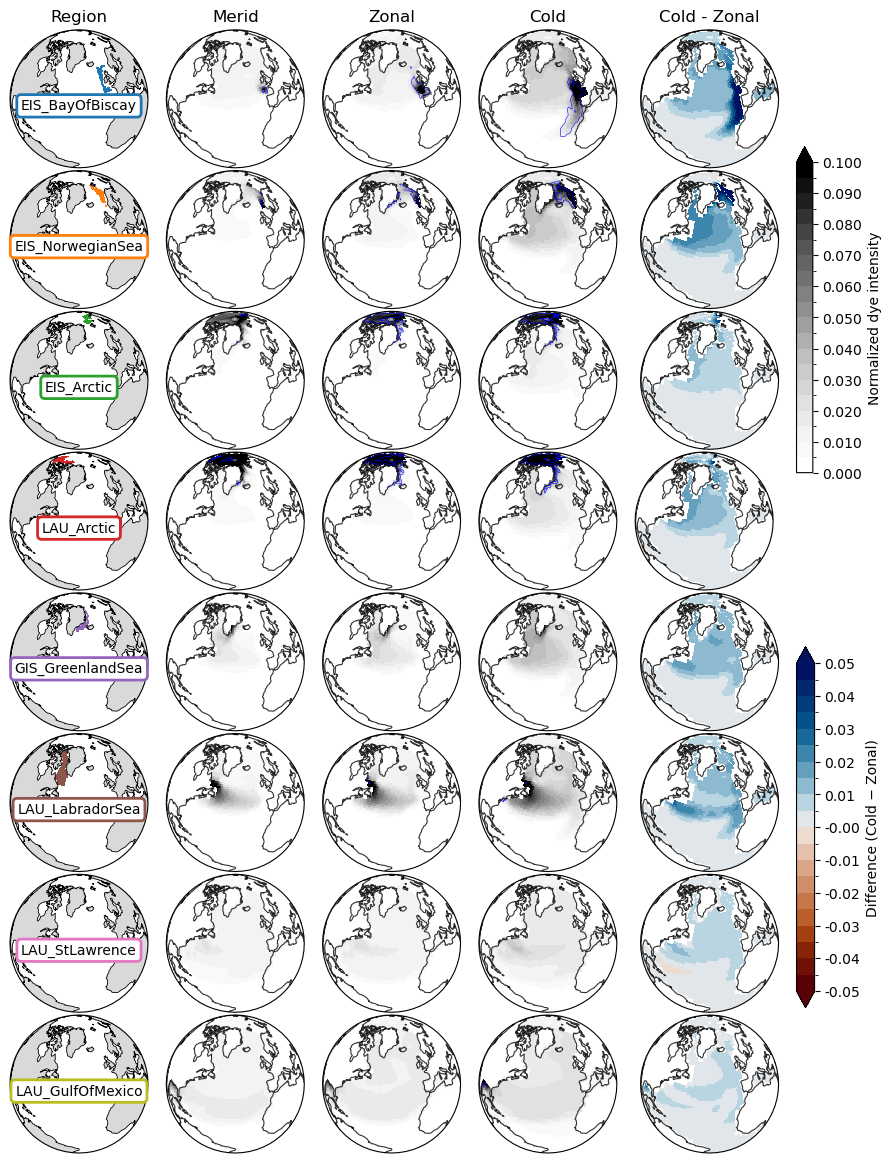

In [29]:
# --------------------------------------------------
# Plot mean dye fields + uncertainty stippling
# + Cold - Zonal difference column
# --------------------------------------------------

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import warnings

# Dye and d18O information
from myconfig.DYES import DYE_TABLE
#DYE_TO_REGION = dict(zip(DYE_TABLE["dye"], DYE_TABLE["region"]))

projection_map = ccrs.NearsidePerspective(
    central_longitude=-35,
    central_latitude=45,
    satellite_height=11000000,
)

# -------------------------
# Dye settings
# -------------------------

bounds = np.arange(0, 0.101, 0.005)
std_threshold = 0.01

normdye_a = mpl.colors.BoundaryNorm(
    boundaries=bounds,
    ncolors=cmc.batlowW_r.N,
)

# Difference colour scale
diff_lim = 0.05
diff_bounds = np.arange(-diff_lim, diff_lim + 0.005, 0.005)

diff_norm = mpl.colors.BoundaryNorm(
    boundaries=diff_bounds,
    ncolors=cmc.broc.N,
)

dye_list = (
    "dye01",
    "dye02",
    "dye03",
    "dye04",
    "dye05",
    "dye06",
    "dye07",
    "dye08",
)

states = ["merid", "zonal", "cold"]


region_names = DYE_TABLE["region"].tolist()[1:]

region_colors = {
    region: color
    for region, color in zip(
        region_names,
        [
            "tab:blue",
            "tab:orange",
            "tab:green",
            "tab:red",
            "tab:purple",
            "tab:brown",
            "tab:pink",
            "tab:olive",
            "tab:cyan",
        ],
    )
}




# -------------------------
# Figure
# -------------------------

figMap, axMap = plt.subplots(
    nrows=len(dye_list),
    ncols=5,
    subplot_kw={"projection": projection_map},
    figsize=(9, 11.7),
)

axMap = np.atleast_2d(axMap)


# --------------------------------------------------
# First column
# --------------------------------------------------

# ==================================================
# Plot regions
# ==================================================

for i, (ax, region) in enumerate(
    zip(axes, region_names)
):

    # -------------------------
    # Region mask
    # -------------------------

    mask = ds_dye_region[region].isel(t=0,depth=0)


    # ensure binary mask
    mask = xr.where(mask > 0, 1, np.nan)


    # -------------------------
    # Plot region
    # -------------------------

    axMap[i,0].pcolormesh(
        ds_dye_region.longitude,
        ds_dye_region.latitude,
        mask,
        transform=ccrs.PlateCarree(),
        cmap=ListedColormap(
            [region_colors[region]]
        ),
        shading="nearest",
        zorder=3,
    )


    # -------------------------
    # Land background
    # -------------------------

    axMap[i,0].add_feature(
        cfeature.LAND,
        facecolor="0.85",
        edgecolor="none",
        zorder=1,
    )


    axMap[i,0].coastlines(
        resolution="110m",
        linewidth=0.6,
        color="k",
        zorder=4,
    )


    # -------------------------
    # Region name box
    # -------------------------

    axMap[i,0].text(
        0.5,
        0.5,
        region,
        transform=axMap[i,0].transAxes,
        ha="center",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor=region_colors[region],
            linewidth=2,
        ),
        zorder=20,
    )





# --------------------------------------------------
# Second three columns
# --------------------------------------------------

for j, mode in enumerate(states):

    for i, dye in enumerate(dye_list):

        ax = axMap[i, j+1]

        # -------------------------
        # Mean field
        # -------------------------

        mean_field = dye_field_lookup[mode]["mean"][dye]

        

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="invalid value encountered in divide",
                category=RuntimeWarning,
            )
        

        mean_smooth = (
            mean_field
            .rolling(latitude=3, longitude=3, center=True,min_periods=1)
            .mean()
        )

        pcm = ax.pcolormesh(
            mean_smooth.longitude,
            mean_smooth.latitude,
            mean_smooth,
            transform=ccrs.PlateCarree(),
            norm=normdye_a,
            #cmap= "Greys", 
            cmap= cmc.batlowW_r,
            shading="nearest",
            zorder=2,
        )

        # -------------------------
        # Experiment spread
        # -------------------------

        std_field = dye_field_lookup[mode]["std"][dye]

        # Stipple (legacy?)
        #stipple_stride = 4

        #mask = std_field > std_threshold

       # xx, yy = np.meshgrid(
       #     mean_field.longitude,
       #     mean_field.latitude,
       # )

        #ax.scatter(
        #xx[::stipple_stride, ::stipple_stride][mask.values[::stipple_stride, ::stipple_stride]],
        #yy[::stipple_stride, ::stipple_stride][mask.values[::stipple_stride, ::stipple_stride]],
        #s=0.1,
        #color="k",
        #marker=".",
        #transform=ccrs.PlateCarree(),
        #zorder=5,
        #)



        # -------------------------
        # Uncertainty contour
        # -------------------------
        
        std_field = dye_field_lookup[mode]["std"][dye]
        
        # only show uncertainty where signal exists
        uncertainty_mask = (
            (std_field > std_threshold)
            &
            (mean_field > 0.005)
        )
        
        
        ax.contour(
            mean_field.longitude,
            mean_field.latitude,
            uncertainty_mask,
            levels=[0.5],
            colors="blue",
            linewidths=0.4,
            linestyles="-",
            transform=ccrs.PlateCarree(),
            zorder=5,
        )

        ax.coastlines(
            resolution="110m",
            linewidth=0.8,
            color="k",
            alpha=0.8,
            zorder=4,
        )

# --------------------------------------------------
# Fourth column: Cold - Zonal
# --------------------------------------------------

for i, dye in enumerate(dye_list):

    ax = axMap[i, 4]

    cold = (
        dye_field_lookup["cold"]["mean"][dye]
        .rolling(latitude=3, longitude=3, center=True)
        .mean()
    )

    zonal = (
        dye_field_lookup["zonal"]["mean"][dye]
        .rolling(latitude=3, longitude=3, center=True)
        .mean()
    )

    diff = cold - zonal

    pcm_diff = ax.pcolormesh(
        diff.longitude,
        diff.latitude,
        diff,
        transform=ccrs.PlateCarree(),
        cmap=cmc.vik_r,
        norm=diff_norm,
        shading="nearest",
        zorder=2,
    )

    # Optional significance stippling:
    #
    # pooled_std = np.sqrt(
    #     dye_field_lookup["cold"]["std"][dye]**2 +
    #     dye_field_lookup["zonal"]["std"][dye]**2
    # )
    #
    # mask = abs(diff) < pooled_std
    #
    # xx, yy = np.meshgrid(diff.longitude, diff.latitude)
    #
    # ax.scatter(
    #     xx[::2, ::2][mask.values[::2, ::2]],
    #     yy[::2, ::2][mask.values[::2, ::2]],
    #     s=0.25,
    #     color="grey",
    #     marker=".",
    #     transform=ccrs.PlateCarree(),
    #     zorder=5,
    # )

    ax.coastlines(
        resolution="110m",
        linewidth=0.8,
        color="k",
        alpha=0.8,
        zorder=4,
    )

# --------------------------------------------------
# Titles
# --------------------------------------------------

titles = ["Region","Merid", "Zonal", "Cold", "Cold - Zonal"]

for j, title in enumerate(titles):
    axMap[0, j].set_title(title)


#for i, label in enumerate(region_names):
#
#    axMap[i, 0].text(
#        -0.18,          # left of the first column
#        0.5,            # vertically centred
#        label,
#        transform=axMap[i, 0].transAxes,
#        ha="right",
#        va="center",
#        fontsize=9,
#    )


# --------------------------------------------------
# Region labels + row colour indicators
# --------------------------------------------------


# --------------------------------------------------
# Colorbar: mean dye fields
# --------------------------------------------------

cb = figMap.colorbar(
    pcm,
    ax=axMap[:3, 4],
    location="right",
    #shrink=0.85,
    pad=0.03,
    extend="max",
    boundaries=bounds,
    ticks=bounds[::2],
)

cb.set_label("Normalized dye intensity")

cb.ax.set_yticklabels(
    [f"{b:.3f}" for b in bounds[::2]]
)

# --------------------------------------------------
# Colorbar: difference
# --------------------------------------------------

cb_diff = figMap.colorbar(
    pcm_diff,
    ax=axMap[4:, 4],
    location="right",
    #shrink=0.85,
    pad=0.08,
    extend="both",
    boundaries=diff_bounds,
    ticks=diff_bounds[::2],
)

cb_diff.set_label("Difference (Cold − Zonal)")

cb_diff.ax.set_yticklabels(
    [f"{b:.2f}" for b in diff_bounds[::2]]
)

# --------------------------------------------------
# Layout
# --------------------------------------------------

plt.subplots_adjust(
    left=0,
    right=0.86,
    wspace=0.05,
    hspace=0.02,
    top=0.98,
    bottom=0.02,
)


plt.savefig(
     "my_output/chapter-four_latestfigures/Fig3_DyePropagation_v3_greys.pdf",
     dpi=300,
     bbox_inches="tight",
 )



#plt.show()

/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered in divide
  x = np.divide(x1, x2, out)
/nfs/annie/eelse/conda/envs/py3/lib/python3.11/site-packages/dask/array/numpy_compat.py:43: RuntimeWarning: invalid value encountered i

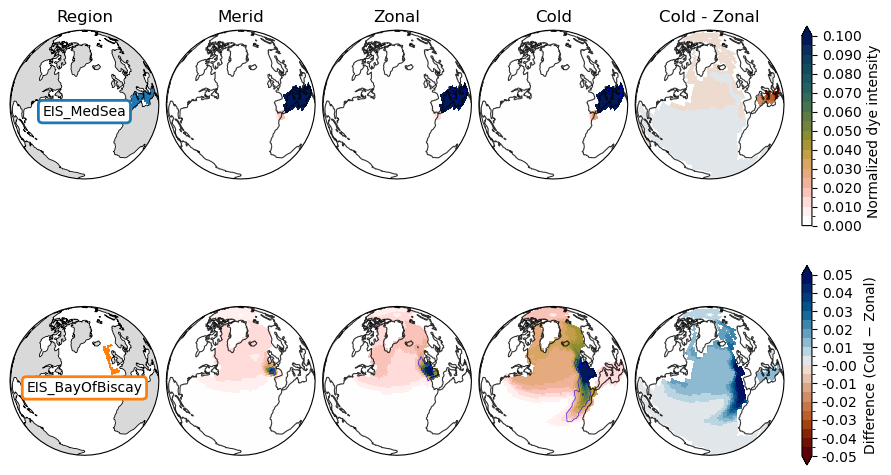

In [33]:
# --------------------------------------------------
# Plot mean dye fields + uncertainty stippling
# + Cold - Zonal difference column
# --------------------------------------------------

import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import numpy as np
import matplotlib as mpl
from matplotlib.colors import ListedColormap
import warnings

# Dye and d18O information
from myconfig.DYES import DYE_TABLE
#DYE_TO_REGION = dict(zip(DYE_TABLE["dye"], DYE_TABLE["region"]))

projection_map = ccrs.NearsidePerspective(
    central_longitude=-35,
    central_latitude=45,
    satellite_height=11000000,
)

# -------------------------
# Dye settings
# -------------------------

bounds = np.arange(0, 0.101, 0.005)
std_threshold = 0.01

normdye_a = mpl.colors.BoundaryNorm(
    boundaries=bounds,
    ncolors=cmc.batlowW_r.N,
)

# Difference colour scale
diff_lim = 0.05
diff_bounds = np.arange(-diff_lim, diff_lim + 0.005, 0.005)

diff_norm = mpl.colors.BoundaryNorm(
    boundaries=diff_bounds,
    ncolors=cmc.broc.N,
)

dye_list = (
    "dye00",
    "dye01",
)

states = ["merid", "zonal", "cold"]


region_names = DYE_TABLE["region"].tolist()[0:2]

region_colors = {
    region: color
    for region, color in zip(
        region_names,
        [
            "tab:blue",
            "tab:orange",
            "tab:green",
            "tab:red",
            "tab:purple",
            "tab:brown",
            "tab:pink",
            "tab:olive",
            "tab:cyan",
        ],
    )
}




# -------------------------
# Figure
# -------------------------

figMap, axMap = plt.subplots(
    nrows=len(dye_list),
    ncols=5,
    subplot_kw={"projection": projection_map},
    figsize=(9, 5.7),
)

axMap = np.atleast_2d(axMap)


# --------------------------------------------------
# First column
# --------------------------------------------------

# ==================================================
# Plot regions
# ==================================================

for i, (ax, region) in enumerate(
    zip(axes, region_names)
):

    # -------------------------
    # Region mask
    # -------------------------

    mask = ds_dye_region[region].isel(t=0,depth=0)


    # ensure binary mask
    mask = xr.where(mask > 0, 1, np.nan)


    # -------------------------
    # Plot region
    # -------------------------

    axMap[i,0].pcolormesh(
        ds_dye_region.longitude,
        ds_dye_region.latitude,
        mask,
        transform=ccrs.PlateCarree(),
        cmap=ListedColormap(
            [region_colors[region]]
        ),
        shading="nearest",
        zorder=3,
    )


    # -------------------------
    # Land background
    # -------------------------

    axMap[i,0].add_feature(
        cfeature.LAND,
        facecolor="0.85",
        edgecolor="none",
        zorder=1,
    )


    axMap[i,0].coastlines(
        resolution="110m",
        linewidth=0.6,
        color="k",
        zorder=4,
    )


    # -------------------------
    # Region name box
    # -------------------------

    axMap[i,0].text(
        0.5,
        0.5,
        region,
        transform=axMap[i,0].transAxes,
        ha="center",
        va="top",
        fontsize=10,
        bbox=dict(
            boxstyle="round,pad=0.3",
            facecolor="white",
            edgecolor=region_colors[region],
            linewidth=2,
        ),
        zorder=20,
    )





# --------------------------------------------------
# Second three columns
# --------------------------------------------------

for j, mode in enumerate(states):

    for i, dye in enumerate(dye_list):

        ax = axMap[i, j+1]

        # -------------------------
        # Mean field
        # -------------------------

        mean_field = dye_field_lookup[mode]["mean"][dye]

        

        with warnings.catch_warnings():
            warnings.filterwarnings(
                "ignore",
                message="invalid value encountered in divide",
                category=RuntimeWarning,
            )
        

        mean_smooth = (
            mean_field
            .rolling(latitude=3, longitude=3, center=True,min_periods=1)
            .mean()
        )

        pcm = ax.pcolormesh(
            mean_smooth.longitude,
            mean_smooth.latitude,
            mean_smooth,
            transform=ccrs.PlateCarree(),
            norm=normdye_a,
            #cmap= "Greys", 
            cmap= cmc.batlowW_r,
            shading="nearest",
            zorder=2,
        )

        # -------------------------
        # Experiment spread
        # -------------------------

        std_field = dye_field_lookup[mode]["std"][dye]

        # Stipple (legacy?)
        #stipple_stride = 4

        #mask = std_field > std_threshold

       # xx, yy = np.meshgrid(
       #     mean_field.longitude,
       #     mean_field.latitude,
       # )

        #ax.scatter(
        #xx[::stipple_stride, ::stipple_stride][mask.values[::stipple_stride, ::stipple_stride]],
        #yy[::stipple_stride, ::stipple_stride][mask.values[::stipple_stride, ::stipple_stride]],
        #s=0.1,
        #color="k",
        #marker=".",
        #transform=ccrs.PlateCarree(),
        #zorder=5,
        #)



        # -------------------------
        # Uncertainty contour
        # -------------------------
        
        std_field = dye_field_lookup[mode]["std"][dye]
        
        # only show uncertainty where signal exists
        uncertainty_mask = (
            (std_field > std_threshold)
            &
            (mean_field > 0.005)
        )
        
        
        ax.contour(
            mean_field.longitude,
            mean_field.latitude,
            uncertainty_mask,
            levels=[0.5],
            colors="blue",
            linewidths=0.4,
            linestyles="-",
            transform=ccrs.PlateCarree(),
            zorder=5,
        )

        ax.coastlines(
            resolution="110m",
            linewidth=0.8,
            color="k",
            alpha=0.8,
            zorder=4,
        )

# --------------------------------------------------
# Fourth column: Cold - Zonal
# --------------------------------------------------

for i, dye in enumerate(dye_list):

    ax = axMap[i, 4]

    cold = (
        dye_field_lookup["cold"]["mean"][dye]
        .rolling(latitude=3, longitude=3, center=True)
        .mean()
    )

    zonal = (
        dye_field_lookup["zonal"]["mean"][dye]
        .rolling(latitude=3, longitude=3, center=True)
        .mean()
    )

    diff = cold - zonal

    pcm_diff = ax.pcolormesh(
        diff.longitude,
        diff.latitude,
        diff,
        transform=ccrs.PlateCarree(),
        cmap=cmc.vik_r,
        norm=diff_norm,
        shading="nearest",
        zorder=2,
    )

    # Optional significance stippling:
    #
    # pooled_std = np.sqrt(
    #     dye_field_lookup["cold"]["std"][dye]**2 +
    #     dye_field_lookup["zonal"]["std"][dye]**2
    # )
    #
    # mask = abs(diff) < pooled_std
    #
    # xx, yy = np.meshgrid(diff.longitude, diff.latitude)
    #
    # ax.scatter(
    #     xx[::2, ::2][mask.values[::2, ::2]],
    #     yy[::2, ::2][mask.values[::2, ::2]],
    #     s=0.25,
    #     color="grey",
    #     marker=".",
    #     transform=ccrs.PlateCarree(),
    #     zorder=5,
    # )

    ax.coastlines(
        resolution="110m",
        linewidth=0.8,
        color="k",
        alpha=0.8,
        zorder=4,
    )

# --------------------------------------------------
# Titles
# --------------------------------------------------

titles = ["Region","Merid", "Zonal", "Cold", "Cold - Zonal"]

for j, title in enumerate(titles):
    axMap[0, j].set_title(title)


#for i, label in enumerate(region_names):
#
#    axMap[i, 0].text(
#        -0.18,          # left of the first column
#        0.5,            # vertically centred
#        label,
#        transform=axMap[i, 0].transAxes,
#        ha="right",
#        va="center",
#        fontsize=9,
#    )


# --------------------------------------------------
# Region labels + row colour indicators
# --------------------------------------------------


# --------------------------------------------------
# Colorbar: mean dye fields
# --------------------------------------------------

cb = figMap.colorbar(
    pcm,
    ax=axMap[:1, 4],
    location="right",
    #shrink=0.85,
    pad=0.03,
    extend="max",
    boundaries=bounds,
    ticks=bounds[::2],
)

cb.set_label("Normalized dye intensity")

cb.ax.set_yticklabels(
    [f"{b:.3f}" for b in bounds[::2]]
)

# --------------------------------------------------
# Colorbar: difference
# --------------------------------------------------

cb_diff = figMap.colorbar(
    pcm_diff,
    ax=axMap[1:, 4],
    location="right",
    #shrink=0.85,
    pad=0.08,
    extend="both",
    boundaries=diff_bounds,
    ticks=diff_bounds[::2],
)

cb_diff.set_label("Difference (Cold − Zonal)")

cb_diff.ax.set_yticklabels(
    [f"{b:.2f}" for b in diff_bounds[::2]]
)

# --------------------------------------------------
# Layout
# --------------------------------------------------

plt.subplots_adjust(
    left=0,
    right=0.86,
    wspace=0.05,
    hspace=0.02,
    top=0.98,
    bottom=0.02,
)


plt.savefig(
     "my_output/chapter-four_latestfigures/Fig3_DyePropagation_Supplementary.pdf",
     dpi=300,
     bbox_inches="tight",
 )



#plt.show()